<a href="https://colab.research.google.com/github/Oleksiy2005/5Lab/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Генеруємо 1000 випадкових записів, що імітують клієнтів банку
np.random.seed(42)
n = 1000

data = {
    'age': np.random.randint(18, 70, n),
    'job': np.random.choice(['admin', 'blue-collar', 'entrepreneur', 'management', 'retired', 'student'], n),
    'marital': np.random.choice(['married', 'single', 'divorced'], n),
    'education': np.random.choice(['primary', 'secondary', 'tertiary'], n),
    'balance': np.random.randint(-1000, 10000, n),
    'housing': np.random.choice(['yes', 'no'], n),
    'loan': np.random.choice(['yes', 'no'], n),
    'duration': np.random.randint(10, 1000, n),
    'y': np.random.choice(['yes', 'no'], n, p=[0.15, 0.85]) # Цільовий стовпець "y", який треба передбачити
}

# Створюємо таблицю та зберігаємо її у віртуальну пам'ять як файл bank_b.csv
df = pd.DataFrame(data)
df.to_csv('bank_b.csv', index=False)

print("Файл bank_b.csv успішно згенеровано! Тепер можна запускати основний код.")

Файл bank_b.csv успішно згенеровано! Тепер можна запускати основний код.


In [3]:
# Імпортуємо модулі для роботи з даними та нейромережею [cite: 26, 27, 28, 29, 31, 32]
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Завантажуємо набір даних [cite: 216]
# Переконайся, що файл bank_b.csv лежить у тій самій папці, що й твій скрипт
data = pd.read_csv("bank_b.csv")

# 2. Виводимо заголовок таблиці (перші 5 записів), щоб подивитися на дані [cite: 217, 37]
data.head()

,age,job,marital,education,balance,housing,loan,duration,y
0,56,entrepreneur,single,secondary,2607,no,no,848,no
1,69,entrepreneur,divorced,tertiary,7043,no,yes,623,no
2,46,admin,single,primary,-478,no,no,235,no
3,32,retired,single,tertiary,4904,no,no,434,no
4,60,management,divorced,primary,3888,yes,no,799,yes


In [5]:
# 5. Перевіряємо збалансованість класів (долю зразків кожного класу)
print(data['y'].value_counts(normalize=True))

# 4. Факторизація текстових стовпців
text_columns = data.select_dtypes(include=['object']).columns.tolist()
if 'y' in text_columns:
    text_columns.remove('y')

data[text_columns] = data[text_columns].apply(lambda col: pd.factorize(col, sort=True)[0])

# 6. Створюємо предиктори (Х) та цілі (Y)
X = data.drop('y', axis=1)
Y = pd.get_dummies(data['y'], prefix='y')

# 7. Розбиваємо на навчальну та тестову множини
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

# 8. Стандартизуємо предиктори Х (нульове середнє та одинична дисперсія)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

y
no     0.833
yes    0.167
Name: proportion, dtype: float64


In [6]:
# 9. Створюємо модель [cite: 225, 79]
model = Sequential()

# Перший прихований прошарок (10 нейронів, активація relu) [cite: 91, 92]
model.add(Dense(10, input_dim=X_train.shape[1], activation="relu"))

# Другий прихований прошарок (5 нейронів) [cite: 93, 95]
model.add(Dense(5, activation="relu"))

# Вихідний прошарок. Кількість нейронів має відповідати кількості класів (2).
# Активація для класифікації - softmax [cite: 97, 98]
model.add(Dense(2, activation="softmax"))

# Компіляція. Оптимізатор 'adam', функція втрат для One hot encoding - 'categorical_crossentropy', метрика - 'accuracy' [cite: 100, 110, 114, 122, 123]
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 10. Навчаємо нейромережу [cite: 228]
# validation_split=0.15 відкушує частину даних для валідації [cite: 124, 126]
history = model.fit(X_train, Y_train, epochs=50, validation_split=0.15, batch_size=16, verbose=2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


46/46 - 2s - 44ms/step - accuracy: 0.5111 - loss: 0.8293 - val_accuracy: 0.6172 - val_loss: 0.7263
Epoch 2/50
46/46 - 0s - 6ms/step - accuracy: 0.6939 - loss: 0.6304 - val_accuracy: 0.7266 - val_loss: 0.5943
Epoch 3/50
46/46 - 0s - 7ms/step - accuracy: 0.8075 - loss: 0.5299 - val_accuracy: 0.7891 - val_loss: 0.5330
Epoch 4/50
46/46 - 0s - 6ms/step - accuracy: 0.8366 - loss: 0.4882 - val_accuracy: 0.8047 - val_loss: 0.5086
Epoch 5/50
46/46 - 0s - 6ms/step - accuracy: 0.8393 - loss: 0.4702 - val_accuracy: 0.8047 - val_loss: 0.5024
Epoch 6/50
46/46 - 0s - 6ms/step - accuracy: 0.8393 - loss: 0.4606 - val_accuracy: 0.8125 - val_loss: 0.4983
Epoch 7/50
46/46 - 0s - 6ms/step - accuracy: 0.8393 - loss: 0.4556 - val_accuracy: 0.8125 - val_loss: 0.4960
Epoch 8/50
46/46 - 0s - 6ms/step - accuracy: 0.8393 - loss: 0.4515 - val_accuracy: 0.8125 - val_loss: 0.4952
Epoch 9/50
46/46 - 0s - 7ms/step - accuracy: 0.8393 - loss: 0.4487 - val_accuracy: 0.8125 - val_loss: 0.4943
Epoch 10/50
46/46 - 0s - 7ms/

Тестова точність: 0.8199999928474426


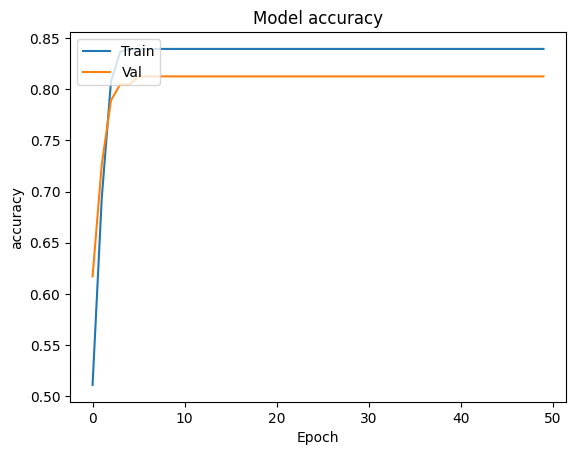

In [8]:
# 11. Оцінюємо якість на тестовій множині
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("Тестова точність:", accuracy)

# 12. Будуємо графік залежності метрики від номеру епохи
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [10]:
# 13. Подаємо на вхід довільний зразок з тестової вибірки
sample = X_test[0:1] # Беремо зразок як список (зріз)
prediction = model.predict(sample)

# Знаходимо клас з максимальною ймовірністю
score = np.max(prediction)
predicted_class_idx = np.argmax(prediction)

# У нас 2 класи. Якщо 'y_no' була першою колонкою, то 0 = no, 1 = yes.
classes = ['no', 'yes']
predicted_label = classes[predicted_class_idx]

# Виводимо результат у необхідному форматі
print(f"Передбачено клас {predicted_label} з достовірністю {score*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Передбачено клас no з достовірністю 86.43%
